<a href="https://colab.research.google.com/github/srj1407/AI_Projects/blob/main/Business_Case_OLA_Ensemble_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basic Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('ola_driver_scaler.csv')

In [ ]:
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


In [ ]:
df.head(1).T

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,0
Unnamed: 0,0
MMM-YY,01/01/19
Driver_ID,1
Age,28.0
Gender,0.0
City,C23
Education_Level,2
Income,57387
Dateofjoining,24/12/18
LastWorkingDate,NaN


In [ ]:
df.shape

(19104, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            19104 non-null  int64  
 1   MMM-YY                19104 non-null  object 
 2   Driver_ID             19104 non-null  int64  
 3   Age                   19043 non-null  float64
 4   Gender                19052 non-null  float64
 5   City                  19104 non-null  object 
 6   Education_Level       19104 non-null  int64  
 7   Income                19104 non-null  int64  
 8   Dateofjoining         19104 non-null  object 
 9   LastWorkingDate       1616 non-null   object 
 10  Joining Designation   19104 non-null  int64  
 11  Grade                 19104 non-null  int64  
 12  Total Business Value  19104 non-null  int64  
 13  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 2.0+ MB


In [ ]:
df.describe()

,Unnamed: 0,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
count,19104.000000,19104.000000,19043.000000,19052.000000,19104.000000,19104.000000,19104.000000,19104.000000,1.910400e+04,19104.000000
mean,9551.500000,1415.591133,34.668435,0.418749,1.021671,65652.025126,1.690536,2.252670,5.716621e+05,2.008899
std,5514.994107,810.705321,6.257912,0.493367,0.800167,30914.515344,0.836984,1.026512,1.128312e+06,1.009832
min,0.000000,1.000000,21.000000,0.000000,0.000000,10747.000000,1.000000,1.000000,-6.000000e+06,1.000000
25%,4775.750000,710.000000,30.000000,0.000000,0.000000,42383.000000,1.000000,1.000000,0.000000e+00,1.000000
50%,9551.500000,1417.000000,34.000000,0.000000,1.000000,60087.000000,1.000000,2.000000,2.500000e+05,2.000000
75%,14327.250000,2137.000000,39.000000,1.000000,2.000000,83969.000000,2.000000,3.000000,6.997000e+05,3.000000
max,19103.000000,2788.000000,58.000000,1.000000,2.000000,188418.000000,5.000000,5.000000,3.374772e+07,4.000000


In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
MMM-YY,0
Driver_ID,0
Age,61
Gender,52
City,0
Education_Level,0
Income,0
Dateofjoining,0
LastWorkingDate,17488


## Insights after basic analysis

1. **Dataset Size**: The dataset contains 19,104 records and 14 columns.

2. **Missing Values**: *LastWorkingDate* has a significant number of missing values (17,488 out of 19,104), which is expected as it's used to define churn.
*Age* (61 missing) and *Gender* (52 missing) also have a small number of missing entries that would need handling.

3. **Data Types**: Date columns (MMM-YY, Dateofjoining, LastWorkingDate) will need to be converted to datetime objects. *City* is of object data type. Will have to be encoded. Rest columns are numerical data types.




# Data Preprocessing

## Steps to be taken:

1. Dropping 'Unnamed: 0' column.
2. Renaming 'MMM-YY' column.
3. Converting time based columns to date time data type.

In [ ]:
df.columns

Index(['Unnamed: 0', 'MMM-YY', 'Driver_ID', 'Age', 'Gender', 'City',
       'Education_Level', 'Income', 'Dateofjoining', 'LastWorkingDate',
       'Joining Designation', 'Grade', 'Total Business Value',
       'Quarterly Rating'],
      dtype='object')

In [ ]:
df = df.drop('Unnamed: 0', axis = 1)
df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


In [ ]:
df= df.rename(columns = {'MMM-YY': 'Monthly_Reporting_Date'})

In [ ]:
df['Monthly_Reporting_Date'].dtype

dtype('O')

In [ ]:
df['Monthly_Reporting_Date'].value_counts()

,count
Monthly_Reporting_Date,
01/01/19,1022
02/01/19,944
03/01/19,870
12/01/20,819
10/01/20,818
08/01/20,812
09/01/20,809
07/01/20,806
11/01/20,805


In [ ]:
df['Monthly_Reporting_Date'].isna().sum()

np.int64(0)

In [ ]:
df['Monthly_Reporting_Date'] = pd.to_datetime(df['Monthly_Reporting_Date'])
df['Monthly_Reporting_Date']

/tmp/ipykernel_2690/2153945012.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Monthly_Reporting_Date'] = pd.to_datetime(df['Monthly_Reporting_Date'])


,Monthly_Reporting_Date
0,2019-01-01
1,2019-02-01
2,2019-03-01
3,2020-11-01
4,2020-12-01
...,...
19099,2020-08-01
19100,2020-09-01
19101,2020-10-01
19102,2020-11-01


In [ ]:
df['Monthly_Reporting_Date'].dtype

dtype('<M8[ns]')

In [ ]:
df['Monthly_Reporting_Date'].isna().sum()

np.int64(0)

In [ ]:
df['Driver_ID'].dtype

dtype('int64')

In [ ]:
df['Driver_ID'].isna().sum()

np.int64(0)

In [ ]:
df['Driver_ID'].value_counts()

,count
Driver_ID,
2784,24
2753,24
2771,24
1745,24
2766,24
...,...
136,1
138,1
2710,1


In [ ]:
df['Age'].dtype

dtype('float64')

In [ ]:
df['Age'].value_counts()

,count
Age,
36.0,1283
33.0,1250
34.0,1234
30.0,1146
32.0,1143
35.0,1138
31.0,1076
29.0,1013
37.0,862


In [ ]:
df['Age'].isna().sum()

np.int64(61)

In [ ]:
df['Gender'].dtype

dtype('float64')

In [ ]:
df['Gender'].value_counts()

,count
Gender,
0.0,11074
1.0,7978


In [ ]:
df['Gender'].isna().sum()

np.int64(52)

In [ ]:
df['City'].dtype

dtype('O')

In [ ]:
df['City'].value_counts()

,count
City,
C20,1008
C29,900
C26,869
C22,809
C27,786
C15,761
C10,744
C12,727
C8,712


In [ ]:
df['City'].unique()

array(['C23', 'C7', 'C13', 'C9', 'C11', 'C2', 'C19', 'C26', 'C20', 'C17',
       'C29', 'C10', 'C24', 'C14', 'C6', 'C28', 'C5', 'C18', 'C27', 'C15',
       'C8', 'C25', 'C21', 'C1', 'C4', 'C3', 'C16', 'C22', 'C12'],
      dtype=object)

In [ ]:
df['City'].isna().sum()

np.int64(0)

In [ ]:
df['Education_Level'].dtype

dtype('int64')

In [ ]:
df['Education_Level'].value_counts()

,count
Education_Level,
1,6864
2,6327
0,5913


In [ ]:
df['Education_Level'].isna().sum()

np.int64(0)

In [ ]:
df['Income'].dtype

dtype('int64')

In [ ]:
df['Income'].isna().sum()

np.int64(0)

In [ ]:
df['Dateofjoining'].dtype

dtype('O')

In [ ]:
df['Dateofjoining'].value_counts()

,count
Dateofjoining,
23/07/15,192
31/07/20,150
07/04/19,146
25/04/16,134
30/07/15,118
...,...
13/02/18,1
26/01/18,1
27/12/20,1


In [ ]:
df['Dateofjoining'].isna().sum()

np.int64(0)

In [ ]:
df['Dateofjoining'] = pd.to_datetime(df['Dateofjoining'])
df['Dateofjoining']

/tmp/ipykernel_2690/4278839208.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dateofjoining'] = pd.to_datetime(df['Dateofjoining'])


,Dateofjoining
0,2018-12-24
1,2018-12-24
2,2018-12-24
3,2020-11-06
4,2020-11-06
...,...
19099,2020-06-08
19100,2020-06-08
19101,2020-06-08
19102,2020-06-08


In [ ]:
df['Dateofjoining'].isna().sum()

np.int64(0)

In [ ]:
df['LastWorkingDate'].dtype

dtype('O')

In [ ]:
df['LastWorkingDate'].isna().sum()

np.int64(17488)

In [ ]:
df['LastWorkingDate'] = pd.to_datetime(df['LastWorkingDate'])
df['LastWorkingDate']

/tmp/ipykernel_2690/3434989888.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['LastWorkingDate'] = pd.to_datetime(df['LastWorkingDate'])


,LastWorkingDate
0,NaT
1,NaT
2,2019-03-11
3,NaT
4,NaT
...,...
19099,NaT
19100,NaT
19101,NaT
19102,NaT


In [ ]:
df['LastWorkingDate'].isna().sum()

np.int64(17488)

In [ ]:
df['Churn'] = df['LastWorkingDate'].isna().astype(int)

In [ ]:
df['Churn'].isna().sum()

np.int64(0)

In [ ]:
df['Joining Designation'].dtype

dtype('int64')

In [ ]:
df['Joining Designation'].value_counts()

,count
Joining Designation,
1,9831
2,5955
3,2847
4,341
5,130


In [ ]:
df['Joining Designation'].isna().sum()

np.int64(0)

In [ ]:
df['Grade'].dtype

dtype('int64')

In [ ]:
df['Grade'].value_counts()

,count
Grade,
2,6627
1,5202
3,4826
4,2144
5,305


In [ ]:
df['Grade'].isna().sum()

np.int64(0)

In [ ]:
df['Total Business Value'].dtype

dtype('int64')

In [ ]:
df['Total Business Value'].isna().sum()

np.int64(0)

In [ ]:
df['Quarterly Rating'].dtype

dtype('int64')

In [ ]:
df['Quarterly Rating'].value_counts()

,count
Quarterly Rating,
1,7679
2,5553
3,3895
4,1977


In [ ]:
df['Quarterly Rating'].isna().sum()

np.int64(0)

In [ ]:
df.head()

,Monthly_Reporting_Date,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating,Churn
0,2019-01-01,1,28.0,0.0,C23,2,57387,2018-12-24,NaT,1,1,2381060,2,1
1,2019-02-01,1,28.0,0.0,C23,2,57387,2018-12-24,NaT,1,1,-665480,2,1
2,2019-03-01,1,28.0,0.0,C23,2,57387,2018-12-24,2019-03-11,1,1,0,2,0
3,2020-11-01,2,31.0,0.0,C7,2,67016,2020-11-06,NaT,2,2,0,1,1
4,2020-12-01,2,31.0,0.0,C7,2,67016,2020-11-06,NaT,2,2,0,1,1


In [ ]:
df.duplicated().sum()

np.int64(0)

# Exploratory Data Analysis(EDA)

In [ ]:
df.head()

,Monthly_Reporting_Date,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating,Churn
0,2019-01-01,1,28.0,0.0,C23,2,57387,2018-12-24,NaT,1,1,2381060,2,1
1,2019-02-01,1,28.0,0.0,C23,2,57387,2018-12-24,NaT,1,1,-665480,2,1
2,2019-03-01,1,28.0,0.0,C23,2,57387,2018-12-24,2019-03-11,1,1,0,2,0
3,2020-11-01,2,31.0,0.0,C7,2,67016,2020-11-06,NaT,2,2,0,1,1
4,2020-12-01,2,31.0,0.0,C7,2,67016,2020-11-06,NaT,2,2,0,1,1


In [ ]:
df['Churn'].value_counts(normalize = True)

,proportion
Churn,
1,0.91541
0,0.08459


Here it can be seen that unbalanced data is there, it should be handles while building model.

In [ ]:
df.dtypes

,0
Monthly_Reporting_Date,datetime64[ns]
Driver_ID,int64
Age,float64
Gender,float64
City,object
Education_Level,int64
Income,int64
Dateofjoining,datetime64[ns]
LastWorkingDate,datetime64[ns]
Joining Designation,int64


## Univariate

In [ ]:
num_cols = ['Age',
 'Education_Level',
 'Income',
 'Joining Designation',
 'Grade',
 'Total Business Value',
 'Quarterly Rating']
num_cols

['Age',
 'Education_Level',
 'Income',
 'Joining Designation',
 'Grade',
 'Total Business Value',
 'Quarterly Rating']

In [ ]:
cat_cols = ['City', 'Gender']
cat_cols

['City', 'Gender']

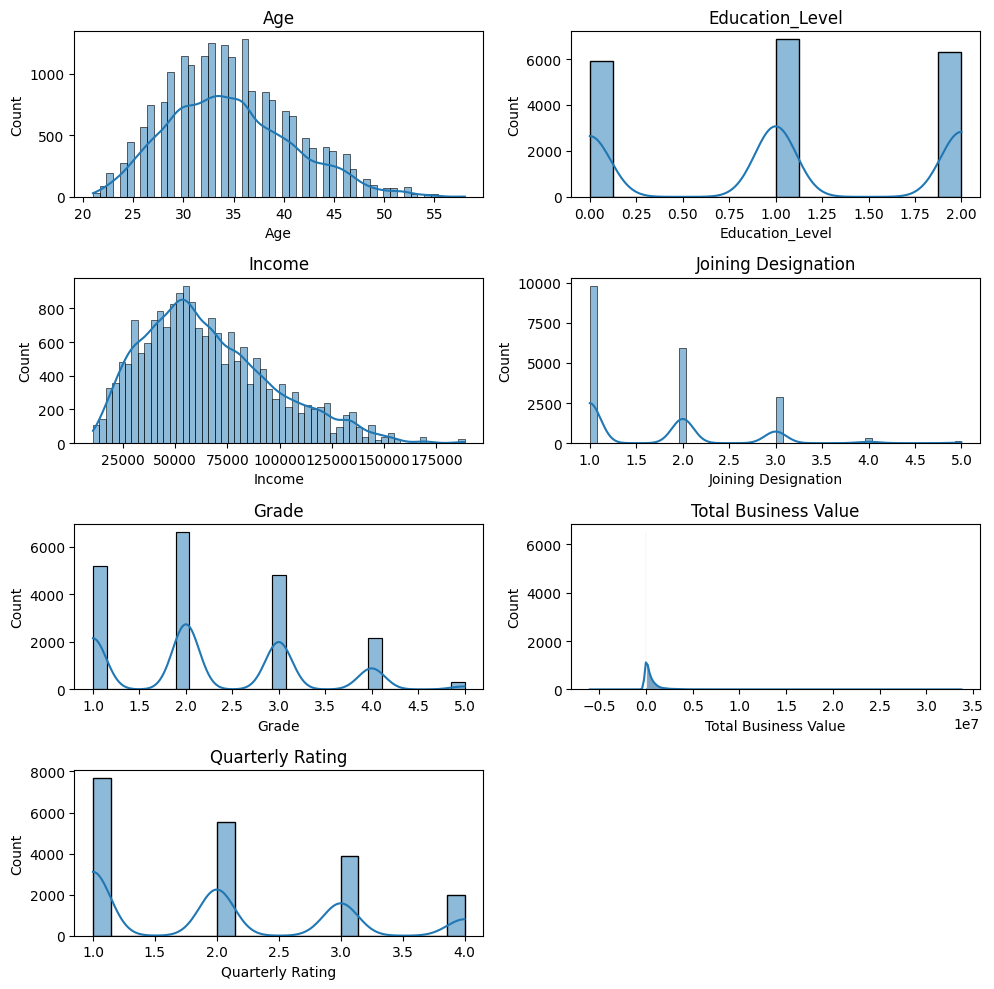

In [ ]:
plt.figure(figsize = (10, 10))
rows = (len(num_cols) + 1) // 2
cols = 2
for i in range(1, len(num_cols) + 1):
  plt.subplot(rows, cols, i)
  sns.histplot(df[num_cols[i-1]], kde = True)
  plt.title(num_cols[i-1])
plt.tight_layout()
plt.show()

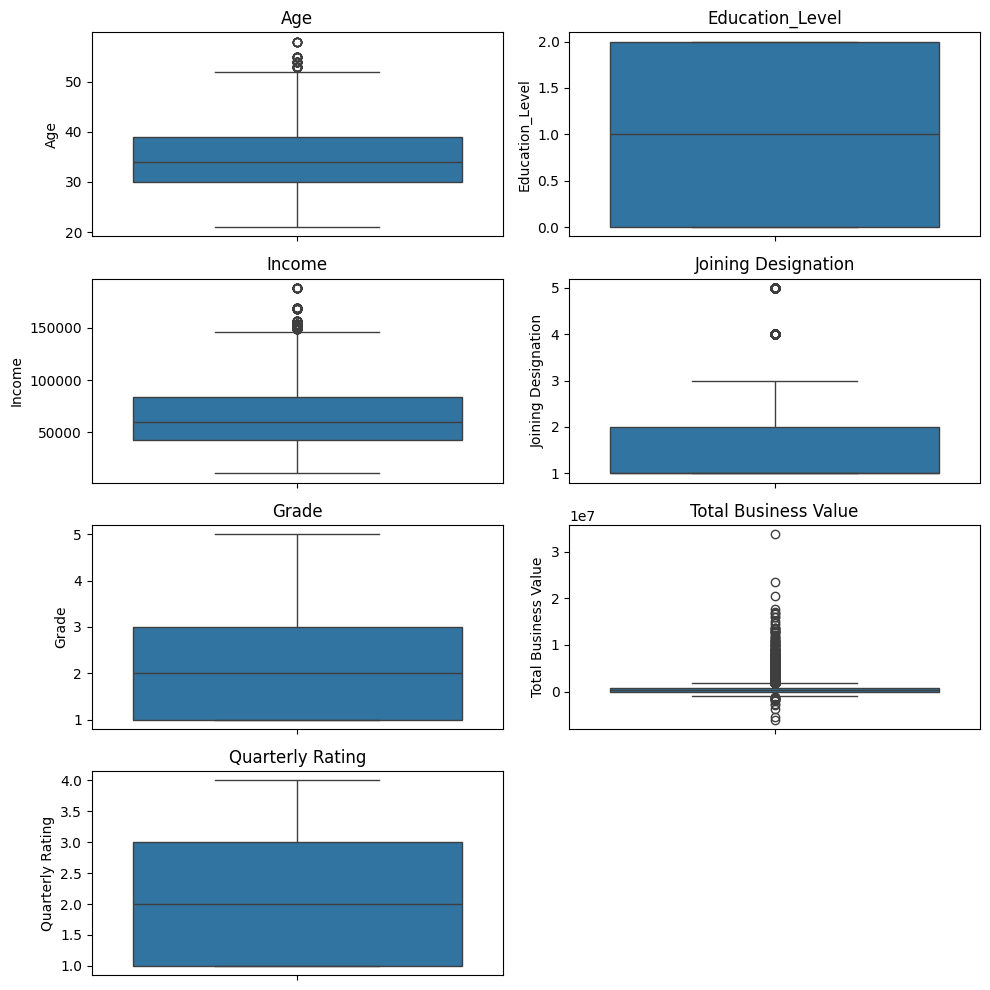

In [ ]:
plt.figure(figsize = (10, 10))
rows = (len(num_cols) + 1) // 2
cols = 2 # Setting two columns
for i in range(1, len(num_cols) + 1):
  plt.subplot(rows, cols, i)
  sns.boxplot(df[num_cols[i-1]])
  plt.title(num_cols[i-1])
plt.tight_layout()
plt.show()

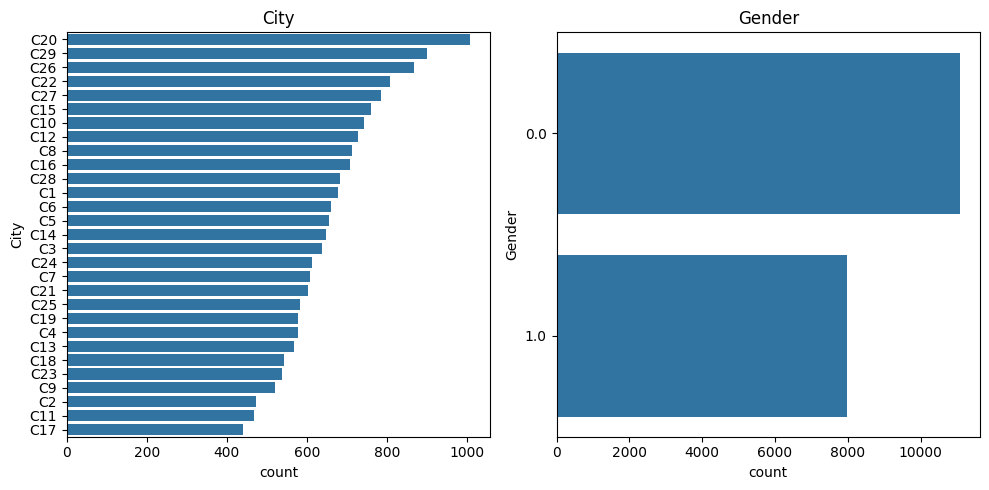

In [ ]:
plt.figure(figsize = (10, 5))
rows = (len(cat_cols) + 1) // 2
cols = 2

cat_cols_to_plot = [col for col in cat_cols]

for i in range(len(cat_cols_to_plot)):
  plt.subplot(rows, cols, i+1)
  sns.countplot(y=df[cat_cols_to_plot[i]], order = df[cat_cols_to_plot[i]].value_counts().index)
  plt.title(cat_cols_to_plot[i])
plt.tight_layout()
plt.show()

## Univariate Analysis Insights

**Numerical Features:**

- **Age**: The distribution of age is somewhat normal, slightly skewed to the right, with most drivers between 30 and 40 years old. There are some outliers on the higher end of the age spectrum.
- **Education_Level**: This feature is categorical with three levels (0, 1, 2). All levels are represented, with levels 1 and 2 appearing more frequently than level 0.
- **Income**: The income distribution is heavily right-skewed, indicating that a majority of drivers have lower to mid-range incomes, while a few drivers have significantly higher incomes. There are noticeable outliers on the higher income side.
- **Joining Designation**: This is a discrete categorical feature (1 to 5). The majority of drivers joined at designation 1, with decreasing numbers for higher designations.
- **Grade**: Similar to joining designation, grade is a discrete feature (1 to 5). Grade 2 appears to be the most common, followed by grade 1 and grade 3.
- **Total Business Value**: This feature shows a highly skewed distribution with a large concentration of values around zero, and a long tail extending to positive values, with significant outliers (both positive and negative) indicating extreme business value fluctuations. This observation highlights the need for outlier treatment, which was later addressed by clipping.
- **Quarterly Rating**: This is a discrete feature ranging from 1 to 4. Ratings of 1 and 2 are the most frequent, followed by 3 and then 4.

**Categorical Features:**

- **City**: The dataset includes drivers from various cities, with 'C20' having the highest number of drivers, followed by 'C29' and 'C26'. This indicates geographical diversity.
- **Gender**: There is an imbalance in gender representation, with Gender 0.0 (presumably male) having a significantly higher count than Gender 1.0 (presumably female).

## Bivariate

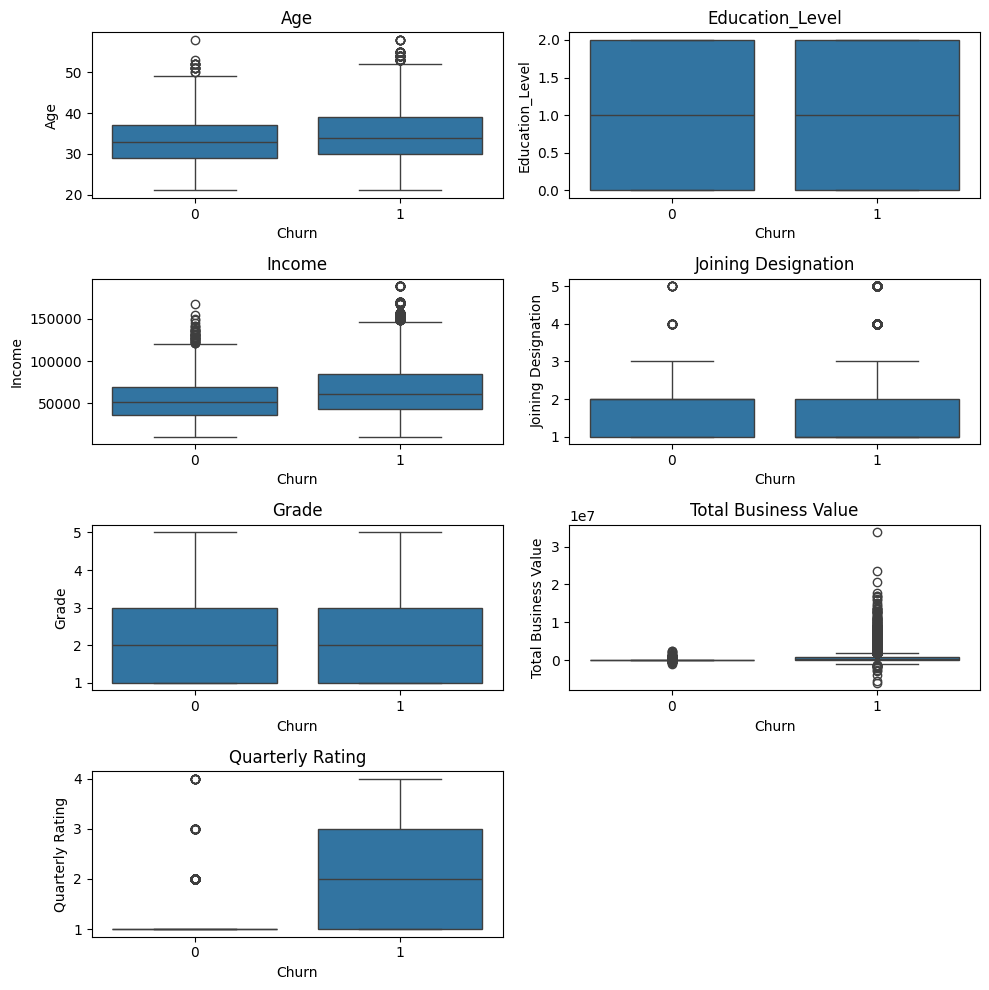

In [ ]:
plt.figure(figsize = (10, 10))
rows = (len(num_cols) + 1) // 2
cols = 2
for i in range(len(num_cols)):
  plt.subplot(rows, cols, i + 1)
  sns.boxplot(x='Churn', y=num_cols[i], data=df)
  plt.title(num_cols[i])
plt.tight_layout()
plt.show()

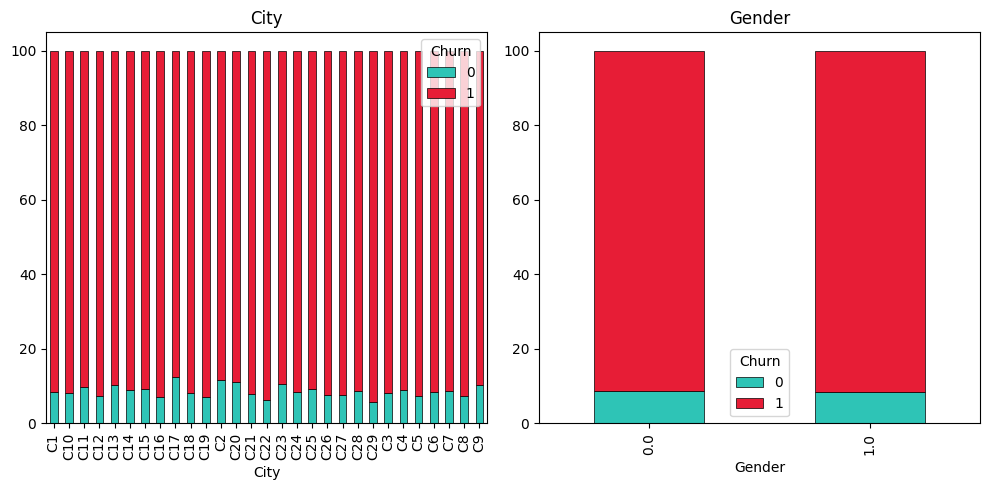

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
axes = axes.flatten()

cat_cols_to_plot = [col for col in cat_cols]

for index, col in enumerate(cat_cols_to_plot):
    cross_tab = pd.crosstab(df[col], df['Churn'], normalize='index') * 100

    cross_tab.plot(
        kind='bar',
        stacked=True,
        ax=axes[index],
        color=['#2ec4b6', '#e71d36'],
        edgecolor='black',
        linewidth=0.5
    )

    # Customise titles and labels for the current plot
    axes[index].set_title(col)

# 4. Handle any leftover empty subplots if your list size doesn't match the grid size
for i in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[i])

# 5. Clean up layout spacing and display
plt.tight_layout()
plt.show()

## Bivariate Analysis Insights

**Numerical Features vs. Churn (Box Plots):**

-   **Age**: There isn't a significant difference in the median age between drivers who churned (0) and those who did not (1). However, the spread of age for non-churned drivers seems slightly wider, with some older outliers. This suggests age alone might not be a strong predictor of churn.
-   **Education_Level**: The box plots for `Education_Level` are very similar for both churned and non-churned groups. This indicates that education level, as represented in this dataset, might not strongly influence churn.
-   **Income**: Non-churned drivers (0) appear to have a slightly higher median income and a wider distribution of incomes compared to churned drivers (1). This suggests that lower income might be associated with a higher likelihood of churn.
-   **Joining Designation**: The distribution of `Joining Designation` is quite similar for both groups, implying it might not be a major differentiator for churn.
-   **Grade**: Drivers who did not churn (0) generally have a higher median `Grade` than those who did churn (1). This suggests that higher grades might be associated with lower churn rates.
-   **Total Business Value**: The `Total Business Value` distributions for both groups show a high concentration around zero. While there are outliers, it's hard to draw strong conclusions directly from this plot due to the heavy skewness, even after initial clipping. It suggests that drivers with very low or negative business values might be more prone to churn.
-   **Quarterly Rating**: Churned drivers (0) tend to have noticeably higher `Quarterly Rating` values, with a higher median and upper quartile, compared to non-churned drivers (0).

**Categorical Features vs. Churn (Stacked Bar Plots):**

-   **City**: Across most cities, the proportion of churned drivers (red part of the bar) is relatively high. While there are slight variations, no single city stands out as having a dramatically lower or higher churn rate compared to others. This suggests churn is a widespread issue across different cities, though further investigation into specific city-level factors could be beneficial.
-   **Gender**: There is no significant difference in the proportion of churn between Gender 0.0 (presumably male) and Gender 1.0 (presumably female). Both genders show a similar high proportion of churn, indicating that gender alone does not appear to be a strong predictor of churn in this dataset.

## Multivariate

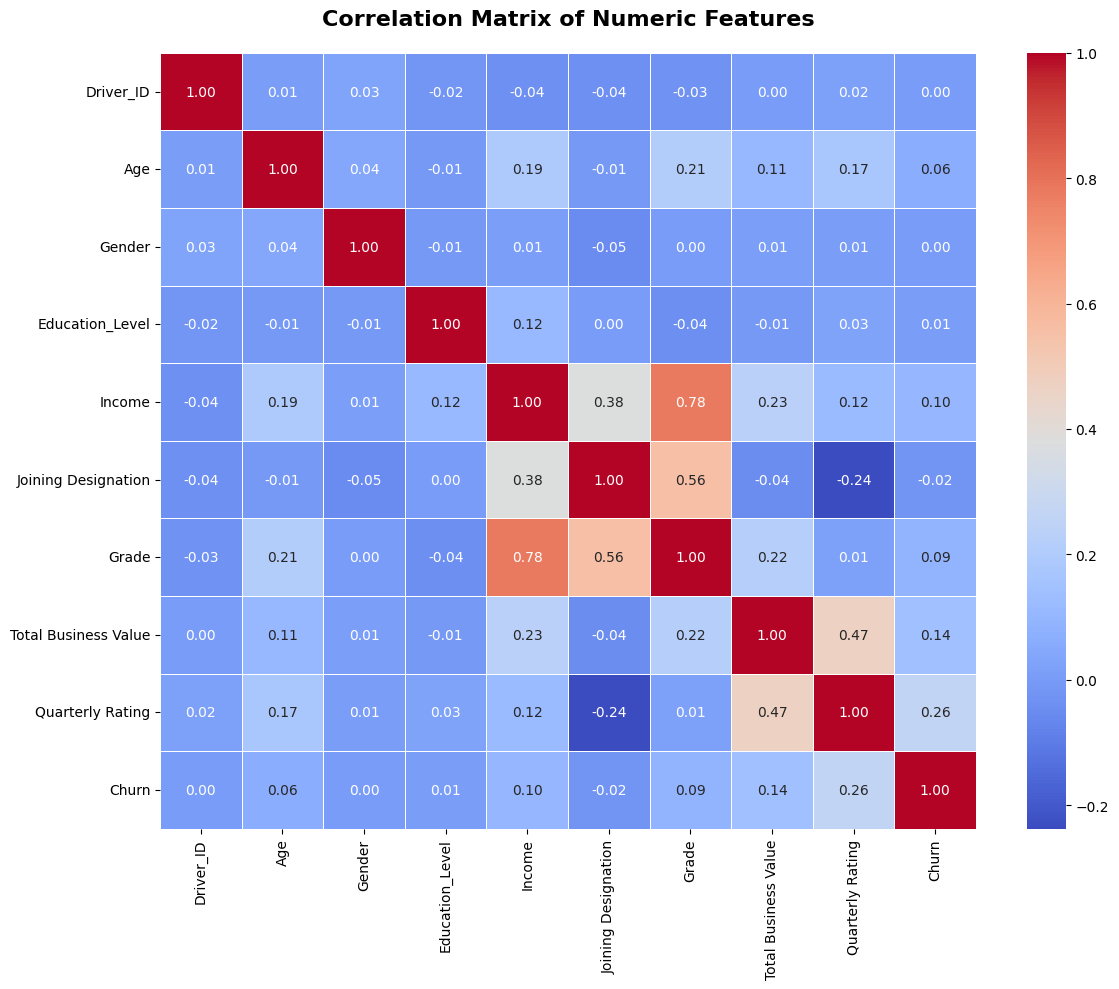

In [ ]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))

# 4. Plot the heatmap using Seaborn
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5,
)

# 5. Add a title and adjust layout
plt.title('Correlation Matrix of Numeric Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## Multivariate Analysis Insights (Correlation Matrix)

**Key Observations from the Correlation Matrix:**

1.  **Strong Inter-Feature Correlations:**
    *   **Income related features**: `Starting_Income`, `Current_Income`, `Income_Change`, and `Income_Growth_Rate` show strong positive correlations among themselves, which is expected as they are derived from the same base feature. `Starting_Income` and `Current_Income` have a very high correlation (0.74), indicating that most drivers' income status doesn't change drastically, or that increases are proportional.
    *   **Grade related features**: `Current_Grade` shows a notable positive correlation with `Income` related features (e.g., `Current_Grade` and `Current_Income` have a correlation of 0.74). This suggests that higher grades are associated with higher incomes, which is a logical progression in a career path.
    *   **Rating related features**: `First_Rating`, `Average_Rating`, and `Last_Rating` are highly correlated with each other (e.75-0.85 range), indicating consistency in driver performance ratings over time. `Rating_Change` and `Rating_Momentum` also show strong positive correlations with `Last_Rating` and `Average_Rating`, suggesting that recent performance and trends align with overall average performance.
    *   `Total_Promotions` is highly correlated with `Current_Grade` (0.56) and `Joining_Designation` (0.83).

2.  **Churn-related Correlations (Indirect Observations from derived features):**
    *   While 'Churn' is not directly present in this specific `X_train_final` correlation matrix (as it was dropped from `X_train` before scaling/encoding), we can infer its relationships by looking at features that were strongly correlated with churn in the bivariate analysis. For example, `Quarterly Rating` showed a relationship with churn, and in this matrix, `Last_Rating` and `Average_Rating` (derived from `Quarterly Rating`) are positively correlated with `Current_Income` (0.38 and 0.38 respectively) and `Grade` (0.22 and 0.25).
    *   `Business_to_Income_Ratio` has a low correlation with most other features, suggesting it captures a unique aspect of a driver's financial performance. It also has a moderate positive correlation with `Lifetime_Business_Value` (0.47) and `Average_Rating` (0.3). This means drivers with higher business values and ratings tend to have a higher business-to-income ratio.

3.  **Low Correlations:**
    *   `Age` shows generally low correlations with most other features, suggesting it acts fairly independently.
    *   `Gender` and `Education_Level` also exhibit very low correlations with other numerical features, implying they are not strongly linearly associated with other aspects of driver performance or tenure captured by the numerical variables. This aligns with the bivariate analysis that showed them not to be strong predictors of churn.

**Implications:**

*   Features like `Business_to_Income_Ratio`, `Joining_Month`, and `City` (after target encoding) appear to capture unique information, which could be valuable for the model.
*   The correlation matrix confirms some of the relationships identified in the bivariate analysis and provides a quantitative measure of these linear relationships across all numerical features.

# Feature Engineering - I

## Feature Engineering Summary

Calculated on the raw timeline data *before* train-test splitting and aggregation to capture chronological changes:

* **`Tenure_Days`:** Calculated dynamically as `Monthly_Reporting_Date` minus `Date Of Joining` to trace the driver's exact career lifespan at that moment in time.
* **`Promotions_Count`:** Measures career velocity by calculating the difference between the active `Grade` and the driver's baseline `Joining Designation`.
* **`Months_At_Current_Grade`:** Evaluates career stagnation by utilizing a window function to track consecutive months spent within a single grade block without an upgrade.


In [ ]:
df = df.sort_values(by = ['Driver_ID', 'Monthly_Reporting_Date'])
df.head(1)

,Monthly_Reporting_Date,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating,Churn
0,2019-01-01,1,28.0,0.0,C23,2,57387,2018-12-24,NaT,1,1,2381060,2,1


Creating new features Tenure and Promotions. Tenure is the number of days passed since the driver joined the company. Promotions is the number of promotions driver got after joining the company. It is the difference between `Grade` and `Joining Designation`.

In [ ]:
df['Tenure'] = (df['Monthly_Reporting_Date'] - df['Dateofjoining']).dt.days
df['Promotions'] = df['Grade'] - df['Joining Designation']
df.head(5)

,Monthly_Reporting_Date,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating,Churn,Tenure,Promotions
0,2019-01-01,1,28.0,0.0,C23,2,57387,2018-12-24,NaT,1,1,2381060,2,1,8,0
1,2019-02-01,1,28.0,0.0,C23,2,57387,2018-12-24,NaT,1,1,-665480,2,1,39,0
2,2019-03-01,1,28.0,0.0,C23,2,57387,2018-12-24,2019-03-11,1,1,0,2,0,67,0
3,2020-11-01,2,31.0,0.0,C7,2,67016,2020-11-06,NaT,2,2,0,1,1,-5,0
4,2020-12-01,2,31.0,0.0,C7,2,67016,2020-11-06,NaT,2,2,0,1,1,25,0


Creating new feature `Months_At_Current_Grade` which tells the number of months passed since driver is at the current grade.

In [ ]:
grade_changed = df['Grade'] != df.groupby('Driver_ID')['Grade'].shift()

In [ ]:
grade_changed

,Grade
0,True
1,False
2,False
3,True
4,False
...,...
19099,False
19100,False
19101,False
19102,False


In [ ]:
grade_blocks = grade_changed.groupby(df['Driver_ID']).cumsum()
grade_blocks

,Grade
0,1
1,1
2,1
3,1
4,1
...,...
19099,1
19100,1
19101,1
19102,1


In [ ]:
df['Months_At_Current_Grade'] = df.groupby(['Driver_ID', grade_blocks]).cumcount() + 1

In [ ]:
df.head()

,Monthly_Reporting_Date,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating,Churn,Tenure,Promotions,Months_At_Current_Grade
0,2019-01-01,1,28.0,0.0,C23,2,57387,2018-12-24,NaT,1,1,2381060,2,1,8,0,1
1,2019-02-01,1,28.0,0.0,C23,2,57387,2018-12-24,NaT,1,1,-665480,2,1,39,0,2
2,2019-03-01,1,28.0,0.0,C23,2,57387,2018-12-24,2019-03-11,1,1,0,2,0,67,0,3
3,2020-11-01,2,31.0,0.0,C7,2,67016,2020-11-06,NaT,2,2,0,1,1,-5,0,1
4,2020-12-01,2,31.0,0.0,C7,2,67016,2020-11-06,NaT,2,2,0,1,1,25,0,2


# Train Test Split

Splitting the data into train and test drivers where a certain subset of unique drivers will be in train with all the rows belonging to that driver and rest will be in test set.

In [ ]:
from sklearn.model_selection import train_test_split

unique_drivers = df['Driver_ID'].unique()
train_drivers, test_drivers = train_test_split(
    unique_drivers,
    test_size = 0.2,
    random_state = 42
)

train_df = df[df['Driver_ID'].isin(train_drivers)].reset_index(drop = True)
test_df = df[df['Driver_ID'].isin(test_drivers)].reset_index(drop = True)

train_df.shape, test_df.shape

((15372, 17), (3732, 17))

# Skewness Treatment

Since `Total Business Value` column is having wide range of outliers we will clip the values between 1 percentile and 99th percentile.

In [ ]:
lower_bound = df['Total Business Value'].quantile(0.01)
upper_bound = df['Total Business Value'].quantile(0.99)

train_df['Total Business Value'] = train_df['Total Business Value'].clip(lower_bound, upper_bound)
test_df['Total Business Value'] = test_df['Total Business Value'].clip(lower_bound, upper_bound)

In [ ]:
train_df.head()

,Monthly_Reporting_Date,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating,Churn,Tenure,Promotions,Months_At_Current_Grade
0,2019-01-01,1,28.0,0.0,C23,2,57387,2018-12-24,NaT,1,1,2381060.0,2,1,8,0,1
1,2019-02-01,1,28.0,0.0,C23,2,57387,2018-12-24,NaT,1,1,0.0,2,1,39,0,2
2,2019-03-01,1,28.0,0.0,C23,2,57387,2018-12-24,2019-03-11,1,1,0.0,2,0,67,0,3
3,2020-11-01,2,31.0,0.0,C7,2,67016,2020-11-06,NaT,2,2,0.0,1,1,-5,0,1
4,2020-12-01,2,31.0,0.0,C7,2,67016,2020-11-06,NaT,2,2,0.0,1,1,25,0,2


# Aggregation

In [ ]:
train_df.head()

,Monthly_Reporting_Date,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating,Churn,Tenure,Promotions,Months_At_Current_Grade
0,2019-01-01,1,28.0,0.0,C23,2,57387,2018-12-24,NaT,1,1,2381060.0,2,1,8,0,1
1,2019-02-01,1,28.0,0.0,C23,2,57387,2018-12-24,NaT,1,1,0.0,2,1,39,0,2
2,2019-03-01,1,28.0,0.0,C23,2,57387,2018-12-24,2019-03-11,1,1,0.0,2,0,67,0,3
3,2020-11-01,2,31.0,0.0,C7,2,67016,2020-11-06,NaT,2,2,0.0,1,1,-5,0,1
4,2020-12-01,2,31.0,0.0,C7,2,67016,2020-11-06,NaT,2,2,0.0,1,1,25,0,2


## Aggregation Strategy

To transform our raw monthly transactional snapshot data into a static, driver-level predictive matrix without introducing **Data Leakage**, we implemented a two-tiered feature engineering framework:

### 1. Driver-ID Groupby Aggregation

Following a leak-free split based entirely on unique `Driver_ID` values, rows were compressed into unified profiles using specific historical window aggregations:

| Feature Category | Columns Generated | Aggregation Logic Applied | Business Value Captured |
| --- | --- | --- | --- |
| **Demographics** | `Age`, `Gender`, `City`, `Education_Level` | `last` / `first` | Baseline driver profile attributes. |
| **Career Flow** | `Current_Grade`, `Total_Tenure_Days`, `Total_Promotions` | `last` / `max` | Total longevity and upward structural trajectory. |
| **Stagnation** | `Months_Stagnant_At_End` | `last` (on `Months_At_Current_Grade`) | Tracks if a driver is currently "stuck" at their role level. |
| **Performance** | `Average_Rating`, `Latest_Rating` | `mean` / `last` | Measures long-term competence vs. recent psychological mindset. |
| **Revenue** | `Lifetime_Business_Value` | `sum` (post-99th percentile outlier capping) | Absolute net value generated (winsorized to stabilize tree gradients). |

### 2. Derived Profile Features (Post-Aggregation Signalling)

Once compressed to one row per driver, final behavioral metrics were created:

* **`Income_Growth_Rate`:** Percentage change between their very first income and final income to isolate wage stagnation.
* **`Rating_Trend` / `Rating_Momentum`:** Tracks directional shifts in performance (Improved, Stagnant, or Dropped) and measures immediate performance drop-offs compared to their long-term average.
* **`Business-to-Income Ratio`:** Renders financial efficiency by dividing average monthly business output by their current income package.
* **`Churn` (The Target):** Binary flag ($1$ if a `LastWorkingDate` exists *anywhere* in that driver's transactional history, $0$ if they remain active).

In [ ]:
def aggregate_driver_data(df):
  sorted_df = df.sort_values(by = ['Driver_ID', 'Monthly_Reporting_Date'])
  aggregated_df = sorted_df.groupby('Driver_ID').agg(
      Age = ('Age', 'last'),
      Gender = ('Gender', 'last'),
      City = ('City', 'last'),
      Education_Level = ('Education_Level', 'last'),

      Starting_Income = ('Income', 'first'),
      Current_Income = ('Income', 'last'),

      Current_Grade = ('Grade', 'last'),
      Total_Tenure_Days = ('Tenure', 'max'),

      First_Rating = ('Quarterly Rating', 'first'),
      Average_Rating = ('Quarterly Rating', 'mean'),
      Last_Rating = ('Quarterly Rating', 'last'),

      Lifetime_Business_Value = ('Total Business Value', 'sum'),

      Total_Promotions = ('Promotions', 'last'),
      Months_Stagnant_At_End = ('Months_At_Current_Grade', 'last'),

      Churn = ('LastWorkingDate', lambda x: 1 if x.notna().any() else 0)
  ).reset_index()

  aggregated_df['Income_Change'] = aggregated_df['Current_Income'] - aggregated_df['Starting_Income']
  aggregated_df['Income_Growth_Rate'] = np.where(
    aggregated_df['Starting_Income'] > 0,
    (aggregated_df['Income_Change'] / aggregated_df['Starting_Income']) * 100,
    0
  )
  aggregated_df['Rating_Change'] = aggregated_df['Last_Rating'] - aggregated_df['First_Rating']
  aggregated_df['Rating_Trend'] = np.select(
      [aggregated_df['Rating_Change'] > 0, aggregated_df['Rating_Change'] < 0],
      [1, -1],
      default = 0
  )
  aggregated_df['Rating_Momentum'] = aggregated_df['Last_Rating'] - aggregated_df['Average_Rating']
  avg_monthly_business = np.where(
      aggregated_df['Total_Tenure_Days'] > 0,
      aggregated_df['Lifetime_Business_Value'] / (aggregated_df['Total_Tenure_Days'] / 30.44),
      0
  )
  aggregated_df['Business_to_Income_Ratio'] = np.where(
      aggregated_df['Current_Income'] > 0,
      avg_monthly_business / aggregated_df['Current_Income'],
      0
  )
  joining_months = sorted_df.groupby('Driver_ID')['Dateofjoining'].first().dt.month.values
  aggregated_df['Joining_Month'] = joining_months
  return aggregated_df

Separating features and labels for train and test dataset.

In [ ]:
X_y_train = aggregate_driver_data(train_df)
X_y_test = aggregate_driver_data(test_df)

X_y_train.shape, X_y_test.shape

((1904, 23), (477, 23))

In [ ]:
X_y_train.head()

,Driver_ID,Age,Gender,City,Education_Level,Starting_Income,Current_Income,Current_Grade,Total_Tenure_Days,First_Rating,...,Total_Promotions,Months_Stagnant_At_End,Churn,Income_Change,Income_Growth_Rate,Rating_Change,Rating_Trend,Rating_Momentum,Business_to_Income_Ratio,Joining_Month
0,1,28.0,0.0,C23,2,57387,57387,1,67,2,...,0,3,1,0,0.0,0,0,0.0,18.850664,12
1,2,31.0,0.0,C7,2,67016,67016,2,25,1,...,0,2,0,0,0.0,0,0,0.0,0.000000,11
2,4,43.0,0.0,C13,2,65603,65603,2,116,1,...,0,5,1,0,0.0,0,0,0.0,1.400010,12
3,5,29.0,0.0,C9,0,46368,46368,1,51,1,...,0,3,1,0,0.0,0,0,0.0,1.549310,1
4,6,31.0,1.0,C11,1,78728,78728,3,123,1,...,0,5,0,0,0.0,1,1,0.4,3.976499,7


In [ ]:
X_train = X_y_train.drop(['Driver_ID', 'Churn'], axis = 1)
y_train = X_y_train['Churn']

X_test = X_y_test.drop(['Driver_ID', 'Churn'], axis = 1)
y_test = X_y_test['Churn']

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1904, 21), (1904,), (477, 21), (477,))

In [ ]:
X_train.head(1).T

,0
Age,28.0
Gender,0.0
City,C23
Education_Level,2
Starting_Income,57387
Current_Income,57387
Current_Grade,1
Total_Tenure_Days,67
First_Rating,2
Average_Rating,2.0


# Encoding and Imputation

## Encoding and Imputation Strategy

To transform our raw monthly transactional snapshot data into a static, driver-level predictive matrix without introducing **Data Leakage**, we implemented a two-tiered feature engineering framework:

### Encoding

* Target encoded City column using sklearn Target Encoder.

* Target encoded Joining Month column.


### Imputation

* Imputed all the aolumns with sklearn KNNImputer.

In [ ]:
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

In [ ]:
from sklearn.preprocessing import TargetEncoder

encoder = TargetEncoder(smooth="auto", random_state=42)
X_train_clean['City'] = encoder.fit_transform(X_train_clean[['City']], y_train)
X_test_clean['City'] = encoder.transform(X_test_clean[['City']])
X_train_clean['Joining_Month'] = encoder.fit_transform(X_train_clean[['Joining_Month']], y_train)
X_test_clean['Joining_Month'] = encoder.transform(X_test_clean[['Joining_Month']])

In [ ]:
from sklearn.preprocessing import MinMaxScaler

X_train_clean = X_train_clean.astype(float)
X_test_clean = X_test_clean.astype(float)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

In [ ]:
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=5, weights='distance')

X_train_imputed = knn_imputer.fit_transform(X_train_scaled)
X_test_imputed = knn_imputer.transform(X_test_scaled)

X_train_final = pd.DataFrame(X_train_imputed, columns=X_train.columns)
X_test_final = pd.DataFrame(X_test_imputed, columns=X_test.columns)

In [ ]:
X_train_final.shape, y_train.shape, X_test_final.shape, y_test.shape

((1904, 21), (1904,), (477, 21), (477,))

In [ ]:
X_train_final.head()

,Age,Gender,City,Education_Level,Starting_Income,Current_Income,Current_Grade,Total_Tenure_Days,First_Rating,Average_Rating,...,Lifetime_Business_Value,Total_Promotions,Months_Stagnant_At_End,Income_Change,Income_Growth_Rate,Rating_Change,Rating_Trend,Rating_Momentum,Business_to_Income_Ratio,Joining_Month
0,0.205882,0.0,0.797884,1.0,0.262508,0.262508,0.00,0.032897,0.333333,0.333333,...,0.043733,0.0,0.086957,0.0,0.0,0.500000,0.5,0.570571,0.255267,0.088260
1,0.294118,0.0,0.588462,1.0,0.316703,0.316703,0.25,0.018040,0.000000,0.000000,...,0.000000,0.0,0.043478,0.0,0.0,0.500000,0.5,0.570571,0.000000,0.151764
2,0.647059,0.0,1.000000,1.0,0.308750,0.308750,0.25,0.050230,0.000000,0.000000,...,0.006428,0.0,0.173913,0.0,0.0,0.500000,0.5,0.570571,0.018958,0.088260
3,0.235294,0.0,0.515108,0.0,0.200489,0.200489,0.00,0.027237,0.000000,0.000000,...,0.002211,0.0,0.086957,0.0,0.0,0.500000,0.5,0.570571,0.020980,0.660712
4,0.294118,1.0,0.409944,0.5,0.382623,0.382623,0.50,0.052706,0.000000,0.200000,...,0.023234,0.0,0.173913,0.0,0.0,0.666667,1.0,0.654254,0.053848,0.308973


In [ ]:
X_train_final.isna().sum()

,0
Age,0
Gender,0
City,0
Education_Level,0
Starting_Income,0
Current_Income,0
Current_Grade,0
Total_Tenure_Days,0
First_Rating,0
Average_Rating,0


In [ ]:
X_test_final.isna().sum()

,0
Age,0
Gender,0
City,0
Education_Level,0
Starting_Income,0
Current_Income,0
Current_Grade,0
Total_Tenure_Days,0
First_Rating,0
Average_Rating,0


# Training

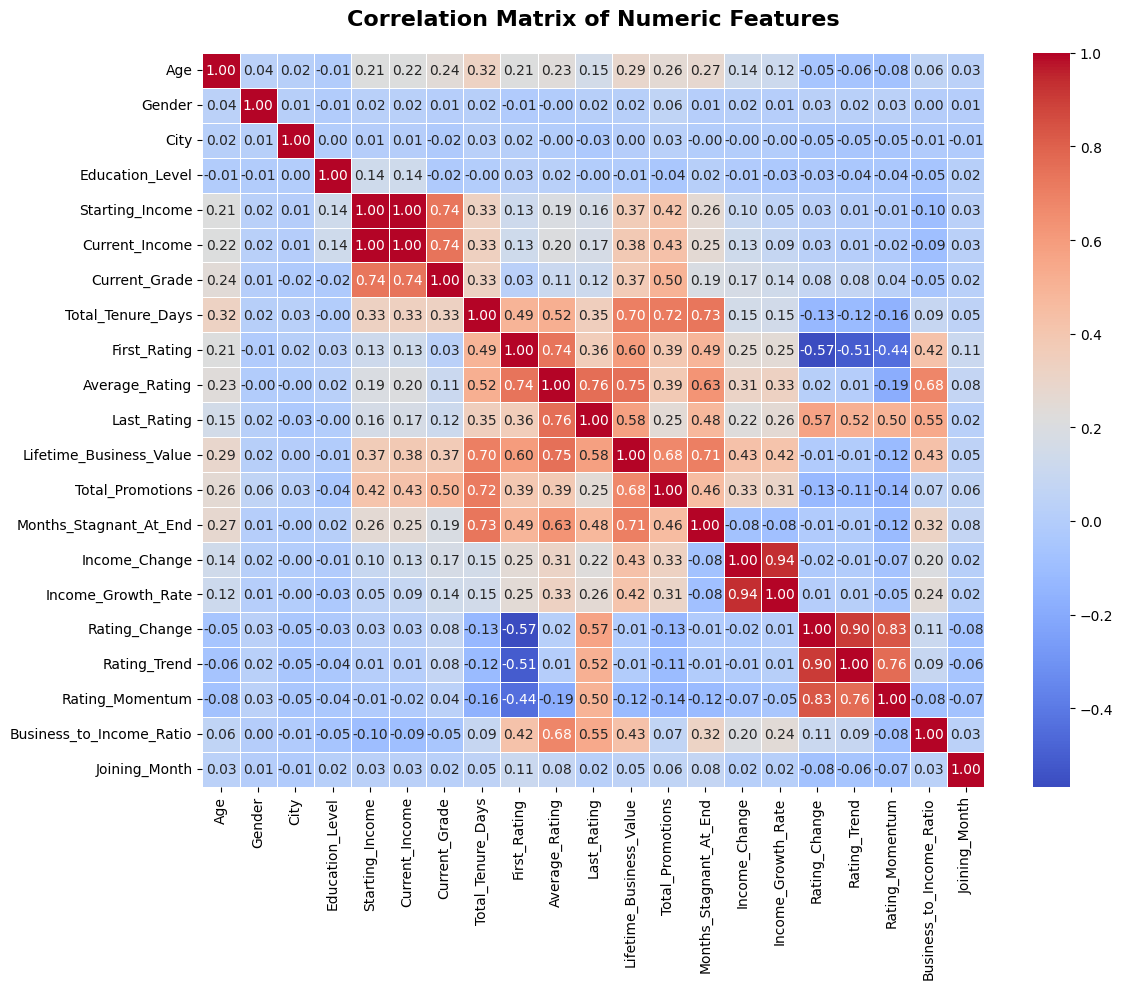

In [ ]:
corr_matrix = X_train_final.corr(numeric_only=True)
plt.figure(figsize=(12, 10))

# 4. Plot the heatmap using Seaborn
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5,
)

# 5. Add a title and adjust layout
plt.title('Correlation Matrix of Numeric Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## Random Forest Classifier

* We will user RandomForestClassifier from sklearn.ensemble with class_weight parameter as `balanced` to handle imbalance in the data.

* We will perform hyperparameter tuning with `n_estimators`, `max_depth`, `min_samples_split` and `max_features`.

* We will use sklearn `GridSearchCV` from sklearn for performing hyperparameter tuning and cross validatopn to find the best hyperparameters.

* `StratifiedKFold` is used as cv strategy to split data in same ratio in all 5 splits.

* We will use `classification_report` and `roc_auc_score` from sklearn to get the accuracy metrics after predicting the test data with the best hyperparameters found.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score

rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 8, 12],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=cv_strategy,
    scoring='roc_auc',
)

grid_search_rf.fit(X_train_final, y_train)

print(f"Best CV ROC-AUC Score: {grid_search_rf.best_score_:.4f}")
print("Best Hyperparameters:", grid_search_rf.best_params_)

best_rf = grid_search_rf.best_estimator_

test_preds_rf = best_rf.predict(X_test_final)
test_probs_rf = best_rf.predict_proba(X_test_final)[:, 1]

print(classification_report(y_test, test_preds_rf))
print(f"Final Test ROC-AUC Score: {roc_auc_score(y_test, test_probs_rf):.4f}")

Best CV ROC-AUC Score: 0.9254
Best Hyperparameters: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.86      0.74      0.80       150
           1       0.89      0.94      0.92       327

    accuracy                           0.88       477
   macro avg       0.87      0.84      0.86       477
weighted avg       0.88      0.88      0.88       477

Final Test ROC-AUC Score: 0.9215


## Random Forest Classifier Results:

**Best CV ROC-AUC Score: 0.9254**

**Best Hyperparameters**:

max_depth: 12

max_features: 'sqrt'

min_samples_split: 5

n_estimators: 200

**Final Test ROC-AUC Score: 0.9215**


**Key Takeaways:**

* The Random Forest model achieved a strong performance with a test ROC-AUC score of approximately 0.9215, indicating good discriminatory power between churned and non-churned drivers.
* The model shows high recall for class 1 (churned drivers) at 0.94, meaning it correctly identifies a large proportion of actual churn cases. This is crucial in churn prediction, where identifying potential churners is often prioritized.
* The precision for class 0 (non-churned drivers) is 0.86, suggesting that when the model predicts a driver will not churn, it is correct 86% of the time.
* Overall accuracy is 0.88, which is a good indication of the model's general correctness.
* The class_weight='balanced' parameter helped in handling the imbalanced dataset, as seen by the relatively balanced f1-score for both classes (0.80 for class 0 and 0.92 for class 1), though there's still a slightly better performance for the majority class (non-churned).
* The hyperparameter tuning process successfully identified a combination of parameters that optimized the model's performance on the training data.

## XG Boost Classifier

* We will user XGBClassifier from sklearn.ensemble with `scale_pos_weight=xgb_weight` parameter to handle imbalance in the data.

* We will perform hyperparameter tuning with `n_estimators`, `max_depth`, `learning_rate` and `subsample`.

* We will use sklearn `GridSearchCV` from sklearn for performing hyperparameter tuning and cross validaton to find the best hyperparameters.

* `StratifiedKFold` is used as cv strategy to split data in same ratio in all 5 splits.

* We will use `classification_report` and `roc_auc_score` from sklearn to get the accuracy metrics after predicting the test data with the best hyperparameters found.

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

num_neg = np.sum(y_train == 0)
num_pos = np.sum(y_train == 1)
xgb_weight = num_neg / num_pos

xgb_model = XGBClassifier(
    scale_pos_weight=xgb_weight,
    random_state=42,
    eval_metric='logloss'
)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='roc_auc',
)

grid_search.fit(X_train_final, y_train)

print(f"Best CV ROC-AUC Score: {grid_search.best_score_:.4f}")
print("Best Hyperparameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_

test_preds = best_model.predict(X_test_final)
test_probs = best_model.predict_proba(X_test_final)[:, 1]

print(classification_report(y_test, test_preds))
print(f"Final Test ROC-AUC Score: {roc_auc_score(y_test, test_probs):.4f}")

Best CV ROC-AUC Score: 0.9397
Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
              precision    recall  f1-score   support

           0       0.84      0.77      0.81       150
           1       0.90      0.93      0.92       327

    accuracy                           0.88       477
   macro avg       0.87      0.85      0.86       477
weighted avg       0.88      0.88      0.88       477

Final Test ROC-AUC Score: 0.9394


## XGBoost Classifier Results:

**Best CV ROC-AUC Score: 0.9397**

**Best Hyperparameters:**

learning_rate: 0.05

max_depth: 7

n_estimators: 200

subsample: 0.8

**Final Test ROC-AUC Score: 0.9394**

**Key Takeaways:**

* The XGBoost model demonstrated excellent performance, achieving a test ROC-AUC score of approximately 0.9394. This indicates strong discriminatory power and a high ability to distinguish between churned and non-churned drivers.

* The model exhibits a high recall for class 1 (churned drivers) at 0.93, meaning it effectively identifies a significant portion of actual churn cases. This is crucial for proactive churn prevention strategies.

* Precision for class 0 (non-churned drivers) is 0.84, suggesting that when the model predicts a driver will not churn, it is correct 84% of the time.

* The overall accuracy is 0.88, which is consistent with the Random Forest model but with slightly improved ROC-AUC. The use of scale_pos_weight successfully addressed the class imbalance, as evidenced by the balanced f1-score for both classes (0.81 for class 0 and 0.92 for class 1).

* The hyperparameter tuning process successfully identified an optimal set of parameters that maximized the model's performance on the validation sets, contributing to its robust generalization capabilities.

# Insighs And Recommendations

**Overall Goal**

The primary objective of this case study was to predict driver churn and provide actionable insights to retain drivers.

**Key Insights from Data Analysis and Feature Engineering**

1. **High Churn Rate:** The dataset indicates a very high churn rate (approximately 91.5%), which is a critical concern for the business. This highlights an urgent need for intervention.

2. **Driver Demographics:** Most drivers are between 30 and 40 years old. There is an imbalance in gender representation, with a higher number of male drivers. However, neither age nor gender showed a strong direct correlation with churn.

3. **Income and Business Value:**

* Lower income appears to be associated with a higher likelihood of churn.
* Total Business Value and Lifetime_Business_Value show a wide range with significant outliers. Drivers with low or negative business value are more prone to churn.
* Income_Growth_Rate and Business_to_Income_Ratio were engineered to capture financial dynamics, showing their potential to be strong predictors.

4. **Career Progression and Stagnation:**

* Grade and Joining Designation are important indicators of career progression. Drivers with higher grades tend to have lower churn rates.
* The engineered feature Months_At_Current_Grade (captured as Months_Stagnant_At_End after aggregation) helps identify drivers who might be stagnating, which could be a factor in churn.

5. **Quarterly Ratings:** Drivers who churned tend to have noticeably higher Quarterly Rating values. This counter-intuitive finding suggests that high-performing drivers might be leaving for better opportunities or due to other dissatisfactions not captured by performance ratings alone. The derived Rating_Change and Rating_Momentum also provide deeper insights into rating trends.

6. **Feature Importance:** The correlation analysis of the engineered features highlights several strong relationships that were leveraged by the models, such as Lifetime_Business_Value and Current_Income with Quarterly Rating.

**Model Performance Summary**

Two machine learning models, Random Forest and XGBoost, were trained and evaluated:

* Random Forest Classifier:

  * Best CV ROC-AUC Score: 0.9254
  * Final Test ROC-AUC Score: 0.9215
  * Recall (Class 1 - Churn): 0.94 (meaning it identified 94% of actual churn cases).

* XGBoost Classifier:

  * Best CV ROC-AUC Score: 0.9397
  * Final Test ROC-AUC Score: 0.9394
  * Recall (Class 1 - Churn): 0.93 (meaning it identified 93% of actual churn cases).
  
**Conclusion:** Both models performed very well, achieving high ROC-AUC scores, indicating strong predictive power. The XGBoost model slightly outperformed Random Forest in terms of overall ROC-AUC score on the test set (0.9394 vs 0.9215).

**Recommendations:**

Based on these insights and the strong predictive capabilities of the models, here are actionable recommendations to mitigate driver churn:

1. Proactive Intervention for High-Performing Drivers: The finding that churned drivers often had higher quarterly ratings is critical. This suggests that top talent might be leaving.

    * Recommendation: Implement an 'early warning system' using the XGBoost model to identify drivers with a high propensity to churn, especially those who are high-rated or have a positive Rating_Momentum. These drivers should be offered retention bonuses, career development opportunities, or direct engagement to understand their grievances.

2. Address Income-Related Dissatisfaction: Lower income is linked to higher churn.

    * Recommendation: Review and potentially revise compensation structures. Introduce performance-based incentives or bonuses for drivers with lower incomes but good performance. Regularly assess Income_Growth_Rate to identify and address wage stagnation.

3. Monitor Business Value: Drivers with low or negative Total Business Value are at higher risk.

    * Recommendation: Provide support, training, or re-allocation to help drivers improve their Total Business Value. This could involve offering better routes, more support for customer acquisition, or optimizing their operational efficiency. The Business_to_Income_Ratio can be a good metric to track financial efficiency.

4. Career Path and Stagnation Management: Months_Stagnant_At_End is an important indicator.

    * Recommendation: Develop clear career progression paths with defined milestones. Implement a system to identify drivers who have been Months_Stagnant_At_End (e.g., 6+ months at the same grade) and offer them training, mentorship, or promotion opportunities to keep them engaged.

5. Utilize the Churn Prediction Model: Deploy the XGBoost model to continuously predict churn risk for all active drivers.

    * Recommendation: Integrate the model's predictions into a driver retention dashboard. Prioritize outreach efforts based on predicted churn probability, allowing for targeted interventions before a driver decides to leave.

By implementing these data-driven recommendations, the business can significantly improve driver retention and foster a more stable and engaged workforce.

In [ ]:
# ⚙️ Convert notebook to high-quality PDF
NOTEBOOK_NAME="Business_Case_OLA_Ensemble_Learning.ipynb"          # 👈 change this if your file has another name
HTML_NAME="Business_Case_OLA_Ensemble_Learning.html"
PDF_NAME="Business_Case_OLA_Ensemble_Learning.pdf"

# Convert notebook → HTML
!jupyter nbconvert --to html "/content/$NOTEBOOK_NAME" --output "/content/$HTML_NAME"

[NbConvertApp] Converting notebook /content/Business_Case_OLA_Ensemble_Learning.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 1517718 bytes to /content/Business_Case_OLA_Ensemble_Learning.html


In [ ]:
import os

# Install wkhtmltopdf
!sudo apt-get update
!sudo apt-get install wkhtmltopdf -y

# Convert HTML → high-quality PDF
!wkhtmltopdf --zoom 2 --dpi 300 "/content/$HTML_NAME" "/content/$PDF_NAME"

# 📥 Download the resulting PDF
from google.colab import files
files.download("/content/" + PDF_NAME)

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [100 kB]
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [38.6 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,109 kB]
Get:14

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>